In [ ]:
import eval_common as _ec
_ec.set_axis("mechanism")     # change to "lob" for the line-of-business axis IGNORE
AXIS = _ec.AXIS
print("AXIS =", AXIS, "| categories:", _ec.MECH_ORDER)

AXIS = mechanism | categories: ['Reliability', 'Bias & Fairness', 'Privacy, Confidentiality & Infringement', 'Security & Misuse', 'Autonomous Actions', 'Governance, Oversight & Explainability']


In [ ]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import minimize
from scipy.linalg import eigvals
from sklearn.metrics import mean_absolute_error, mean_squared_error

RANDOM_SEED = 42
RNG = np.random.default_rng(RANDOM_SEED)

DATA_PATH = Path("incidents_classified.csv")
OUTPUT_DIR = Path("model_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

DATE_COL = "date"
TARGET_COL = "mechanism"

import eval_common as _ec
MECH_ORDER = _ec.MECH_ORDER
MECH_KEEP = _ec.MECH_ORDER
NAMED_MECHS = _ec.NAMED_MECHS

BETA_GRID = np.array([1/7, 1/14, 1/30, 1/60, 1/90], dtype=float)

RIDGE_GRID = [0.01, 0.1, 1.0]
N_STARTS = 3
N_SIMS = 300

df = _ec.load_incidents()
df["mechanism"] = df[TARGET_COL] 


print("Rows:", len(df))
print("Date range:", df[DATE_COL].min(), "to", df[DATE_COL].max())
print(df["mechanism"].value_counts().reindex(MECH_ORDER))

Rows: 1577
Date range: 2016-01-01 00:00:00 to 2026-07-30 00:00:00
mechanism
Reliability                                218
Bias & Fairness                            168
Privacy, Confidentiality & Infringement    223
Security & Misuse                          664
Autonomous Actions                         222
Governance, Oversight & Explainability      82
Name: count, dtype: int64


In [37]:
counts = _ec.build_counts(df)
full_months = pd.period_range(counts.index.min(), counts.index.max(), freq="M")
print(counts.shape, counts.index[0], "->", counts.index[-1])

from sklearn.metrics import mean_absolute_error, mean_squared_error
evaluate = _ec.evaluate
mlog = _ec.mlog

(127, 6) 2016-01 -> 2026-07


In [38]:
def dates_to_times(data, origin=None):
    x = data.sort_values([DATE_COL, "incident_id"]).copy()

    if origin is None:
        origin = x[DATE_COL].min().normalize()

    times = (
        (x[DATE_COL] - origin)
        .dt.total_seconds()
        .to_numpy()
        / 86400.0
    )

    _, inverse, tie_counts = np.unique(
        times, return_inverse=True, return_counts=True
    )

    jitter = np.zeros_like(times)
    for group, count in enumerate(tie_counts):
        idx = np.flatnonzero(inverse == group)
        if count > 1:
            jitter[idx] = np.linspace(0, 1e-5, count, endpoint=False)

    return times + jitter, origin

all_times, origin = dates_to_times(df)
T_END = float((df[DATE_COL].max().normalize() - origin).days + 1)

print("Observation horizon in days:", T_END)

Observation horizon in days: 3864.0


In [39]:
def poisson_event_loglik(times, horizon):
    rate = max(len(times) / horizon, 1e-15)
    loglik = len(times) * np.log(rate) - rate * horizon
    return {
        "model": "homogeneous_poisson",
        "rate": rate,
        "loglik": loglik,
        "n_parameters": 1,
        "aic": 2 - 2 * loglik,
    }

def trend_poisson_integral(b0, b1, start, end, scale):
    if abs(b1) < 1e-10:
        return np.exp(b0) * (end - start)

    return (
        np.exp(b0) * scale / b1
        * (np.exp(b1 * end / scale) - np.exp(b1 * start / scale))
    )

def trend_poisson_nll(theta, times, horizon):
    b0, b1 = theta
    log_intensity = b0 + b1 * times / horizon
    compensator = trend_poisson_integral(b0, b1, 0.0, horizon, horizon)
    nll = -(log_intensity.sum() - compensator)
    return nll if np.isfinite(nll) else 1e100

def fit_trend_poisson(times, horizon):
    rate = max(len(times) / horizon, 1e-8)
    result = minimize(
        trend_poisson_nll,
        np.array([np.log(rate), 0.0]),
        args=(times, horizon),
        method="L-BFGS-B",
        bounds=[(-30, 10), (-20, 20)],
    )

    b0, b1 = result.x
    loglik = -result.fun

    return {
        "model": "trend_poisson",
        "success": result.success,
        "message": str(result.message),
        "b0": b0,
        "b1": b1,
        "loglik": loglik,
        "n_parameters": 2,
        "aic": 4 - 2 * loglik,
    }

poisson_event_baseline = poisson_event_loglik(all_times, T_END)
trend_poisson_fit = fit_trend_poisson(all_times, T_END)

display(pd.DataFrame([poisson_event_baseline, trend_poisson_fit]))

,model,rate,loglik,n_parameters,aic,success,message,b0,b1
0,homogeneous_poisson,0.408126,-2990.273665,1,5982.547331,NaN,NaN,NaN,NaN
1,trend_poisson,NaN,-2500.627126,2,5005.254252,True,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...,-2.762012,3.021559


In [40]:
def univariate_hawkes_nll(theta, times, horizon, beta):
    mu = np.exp(theta[0])
    eta = 0.995 / (1.0 + np.exp(-theta[1]))
    alpha = eta * beta

    state = 0.0
    log_intensity = 0.0
    previous_time = 0.0

    for i, event_time in enumerate(times):
        if i:
            state = np.exp(-beta * (event_time - previous_time)) * (1.0 + state)

        intensity = mu + alpha * state
        if intensity <= 0 or not np.isfinite(intensity):
            return 1e100

        log_intensity += np.log(intensity)
        previous_time = event_time

    compensator = (
        mu * horizon
        + (alpha / beta) * np.sum(1.0 - np.exp(-beta * (horizon - times)))
    )
    nll = -(log_intensity - compensator)
    return nll if np.isfinite(nll) else 1e100

def fit_univariate_hawkes(times, horizon, beta):
    rate = max(len(times) / horizon, 1e-8)
    initial_eta = 0.5
    initial_logit = np.log(initial_eta / (0.995 - initial_eta))

    result = minimize(
        univariate_hawkes_nll,
        np.array([np.log(rate * 0.5), initial_logit]),
        args=(times, horizon, beta),
        method="L-BFGS-B",
        bounds=[(-30, 10), (-20, 20)],
    )

    mu = np.exp(result.x[0])
    eta = 0.995 / (1.0 + np.exp(-result.x[1]))
    alpha = eta * beta
    loglik = -result.fun

    return {
        "success": result.success,
        "message": str(result.message),
        "mu": mu,
        "alpha": alpha,
        "beta": beta,
        "branching_ratio_eta": eta,
        "decay_half_life_days": np.log(2) / beta,
        "loglik": loglik,
        "n_parameters": 2,
        "aic": 4 - 2 * loglik,
    }

def tune_univariate_beta(times, horizon, beta_grid=BETA_GRID):
    fits = [fit_univariate_hawkes(times, horizon, float(beta)) for beta in beta_grid]
    table = pd.DataFrame(fits).sort_values("aic").reset_index(drop=True)
    return fits[int(np.argmin([fit["aic"] for fit in fits]))], table

uni_fit, beta_tuning = tune_univariate_beta(all_times, T_END)

display(beta_tuning)
display(pd.DataFrame([uni_fit]))

,success,message,mu,alpha,beta,branching_ratio_eta,decay_half_life_days,loglik,n_parameters,aic
0,True,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...,0.022486,0.016583,0.016667,0.995000,41.588831,-2469.771179,2,4943.542359
1,True,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...,0.025620,0.011056,0.011111,0.995000,62.383246,-2471.799308,2,4947.598615
2,True,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...,0.023574,0.033167,0.033333,0.995000,20.794415,-2473.063155,2,4950.126311
3,True,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...,0.034265,0.071071,0.071429,0.995000,9.704061,-2489.638914,2,4983.277827
4,True,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...,0.078950,0.115794,0.142857,0.810561,4.852030,-2507.374851,2,5018.749703


,success,message,mu,alpha,beta,branching_ratio_eta,decay_half_life_days,loglik,n_parameters,aic
0,True,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...,0.022486,0.016583,0.016667,0.995,41.588831,-2469.771179,2,4943.542359


In [41]:
def homogeneous_poisson_test_loglik(train_times, test_times, train_horizon, test_start, test_end):
    rate = max(len(train_times) / train_horizon, 1e-15)
    return len(test_times) * np.log(rate) - rate * (test_end - test_start)

def trend_poisson_test_loglik(fit, test_times, test_start, test_end, scale):
    b0, b1 = fit["b0"], fit["b1"]
    log_intensity = (b0 + b1 * test_times / scale).sum()
    compensator = trend_poisson_integral(b0, b1, test_start, test_end, scale)
    return log_intensity - compensator

def hawkes_test_loglik(train_times, test_times, test_start, test_end, mu, alpha, beta):
    history = list(np.sort(train_times[train_times < test_start]))
    log_intensity = 0.0

    for event_time in np.sort(test_times):
        previous = np.asarray(history)
        excitation = 0.0 if len(previous) == 0 else np.exp(-beta * (event_time - previous)).sum()
        log_intensity += np.log(max(mu + alpha * excitation, 1e-15))
        history.append(float(event_time))

    all_events = np.concatenate([train_times[train_times < test_start], test_times])
    excitation_integral = 0.0

    for event_time in all_events:
        lower = max(test_start, event_time)
        if lower < test_end:
            excitation_integral += (
                alpha / beta
                * (
                    np.exp(-beta * (lower - event_time))
                    - np.exp(-beta * (test_end - event_time))
                )
            )

    compensator = mu * (test_end - test_start) + excitation_integral
    return log_intensity - compensator

rows = []

for (yr, half) in _ec.TEST_FOLDS:
    fold_str = _ec.fold_label(yr, half)
    fstart, fend = _ec.fold_bounds(yr, half)

    train_data = df[df["month_period"] < fstart]
    test_data  = df[(df["month_period"] >= fstart) & (df["month_period"] <= fend)]

    if train_data.empty or test_data.empty:
        continue

    train_times, _ = dates_to_times(train_data, origin)
    test_times, _  = dates_to_times(test_data, origin)

    test_start = float((fstart.to_timestamp() - origin).days)
    test_end   = float(((fend + 1).to_timestamp() - origin).days)   # first day after fold

    best_hawkes, _ = tune_univariate_beta(train_times, test_start)
    trend_fit = fit_trend_poisson(train_times, test_start)

    p_ll = homogeneous_poisson_test_loglik(train_times, test_times, test_start, test_start, test_end)
    t_ll = trend_poisson_test_loglik(trend_fit, test_times, test_start, test_end, test_start)
    h_ll = hawkes_test_loglik(train_times, test_times, test_start, test_end,
                              best_hawkes["mu"], best_hawkes["alpha"], best_hawkes["beta"])

    n_test = len(test_times)
    rows.append({
        "fold": fold_str,
        "n_train": len(train_times),
        "n_test": n_test,
        "selected_beta": best_hawkes["beta"],
        "training_eta": best_hawkes["branching_ratio_eta"],
        "homogeneous_poisson_loglik_per_event": p_ll / n_test,
        "trend_poisson_loglik_per_event": t_ll / n_test,
        "hawkes_loglik_per_event": h_ll / n_test,
    })

hawkes_event_backtest = pd.DataFrame(rows)

display(hawkes_event_backtest)
display(
    hawkes_event_backtest[
        [
            "homogeneous_poisson_loglik_per_event",
            "trend_poisson_loglik_per_event",
            "hawkes_loglik_per_event",
        ]
    ].mean().to_frame("mean")
)

,fold,n_train,n_test,selected_beta,training_eta,homogeneous_poisson_loglik_per_event,trend_poisson_loglik_per_event,hawkes_loglik_per_event
0,2020-H1,181,45,0.142857,0.027198,-2.589436,-2.589436,-2.563735
1,2020-H2,226,47,0.142857,0.232841,-2.522250,-2.413534,-2.409788
2,2021-H1,273,42,0.142857,0.305093,-2.544911,-2.465577,-2.548963
3,2021-H2,315,38,0.142857,0.294238,-2.611915,-2.599385,-2.616253
4,2022-H1,353,52,0.011111,0.585061,-2.386645,-2.257423,-2.292757
5,2022-H2,405,54,0.011111,0.654235,-2.349566,-2.219400,-2.242681
6,2023-H1,459,101,0.011111,0.717624,-2.039231,-1.724925,-1.651668
7,2023-H2,560,73,0.016667,0.825074,-2.102571,-1.919212,-1.939127
8,2024-H1,633,146,0.016667,0.835305,-1.799602,-1.339160,-1.253079
9,2024-H2,779,154,0.016667,0.995000,-1.682292,-1.209519,-1.186342


,mean
homogeneous_poisson_loglik_per_event,-2.066633
trend_poisson_loglik_per_event,-1.816335
hawkes_loglik_per_event,-1.800752


In [ ]:
MARKED_BETA_GRID = [1/14, 1/30, 1/60, 1/90]
MARKED_RIDGE_GRID = [0.01, 0.1, 1.0]
RHO_MAX_GRID = [0.80, 0.90, 0.95]
SMOOTHING_GRID = [0.0, 0.05, 0.10, 0.20]

N_STARTS_TUNE = 2
N_STARTS_FINAL = 4
N_SIMS_TUNE = 100
N_SIMS_FINAL = 400

def prepare_marked_events(data, origin):
    x = data.sort_values([DATE_COL, "incident_id"]).copy()
    x["time"] = (x[DATE_COL] - origin).dt.total_seconds() / 86400.0
    x["time"] += x.groupby("time").cumcount() * 1e-5
    mark_map = {mark: index for index, mark in enumerate(MECH_ORDER)}
    cat_col = "mechanism" if "mechanism" in x.columns else _ec.TARGET_COL
    x["mark_idx"] = x[cat_col].map(mark_map).astype(int)
    return x["time"].to_numpy(float), x["mark_idx"].to_numpy(int)

def unpack_marked(theta, dimension, beta, rho_max):
    mu = np.exp(theta[:dimension])
    K_raw = np.exp(theta[dimension:].reshape(dimension, dimension))
    rho_raw = float(np.max(np.abs(eigvals(K_raw))).real)
    if rho_raw > rho_max:
        K = K_raw * rho_max / (rho_raw + 1e-12)
    else:
        K = K_raw
    A = beta * K
    return mu, A, K

def marked_hawkes_nll(theta, times, marks, horizon, dimension, beta, ridge, rho_max):
    mu, A, K = unpack_marked(theta, dimension, beta, rho_max)
    state = np.zeros(dimension)
    previous_time = 0.0
    log_intensity = 0.0
    for i, (event_time, event_mark) in enumerate(zip(times, marks)):
        if i:
            state *= np.exp(-beta * (event_time - previous_time))
        intensity = mu + A @ state
        marked_intensity = intensity[event_mark]
        if marked_intensity <= 0 or not np.isfinite(marked_intensity):
            return 1e100
        log_intensity += np.log(marked_intensity)
        state[event_mark] += 1.0
        previous_time = event_time
    tail = 1.0 - np.exp(-beta * (horizon - times))
    event_compensator = sum((A[:, mark].sum() / beta) * tail_value
                            for mark, tail_value in zip(marks, tail))
    loglik = log_intensity - mu.sum() * horizon - event_compensator
    penalty = ridge * np.sum(K ** 2)
    objective = -loglik + penalty
    return objective if np.isfinite(objective) else 1e100

def fit_marked_hawkes(times, marks, horizon, beta, ridge, rho_max, n_starts):
    dimension = len(MECH_ORDER)
    rates = np.bincount(marks, minlength=dimension) / max(horizon, 1e-12)
    best = None
    seed = int(RANDOM_SEED + round(beta * 100000) + round(ridge * 1000) + round(rho_max * 100))
    local_rng = np.random.default_rng(seed)
    for _ in range(n_starts):
        mu0 = np.maximum(rates * local_rng.uniform(0.4, 0.9, dimension), 1e-5)
        K0 = np.full((dimension, dimension), 0.01)
        np.fill_diagonal(K0, local_rng.uniform(0.05, 0.20, dimension))
        theta0 = np.r_[np.log(mu0), np.log(K0.ravel())]
        result = minimize(
            marked_hawkes_nll, theta0,
            args=(times, marks, horizon, dimension, beta, ridge, rho_max),
            method="L-BFGS-B",
            bounds=([(-20, 5)] * dimension + [(-12, 0)] * (dimension * dimension)),
            options={"maxiter": 1000, "maxfun": 80000, "ftol": 1e-8})
        if best is None or result.fun < best.fun:
            best = result
    if best is None:
        raise RuntimeError("No marked Hawkes fit was returned.")
    mu, A, K = unpack_marked(best.x, dimension, beta, rho_max)
    spectral_radius = float(np.max(np.abs(eigvals(K))).real)
    return {
        "result": best, "success": bool(best.success), "message": str(best.message),
        "mu": mu, "A": A, "K": K,
        "beta": float(beta), "ridge": float(ridge), "rho_max": float(rho_max),
        "spectral_radius": spectral_radius, "objective": float(best.fun),
    }

In [ ]:
def simulate_marked_interval(fit, history_times, history_marks, start, end, rng):
    mu = fit["mu"]; A = fit["A"]; beta = fit["beta"]
    dimension = len(mu); state = np.zeros(dimension)
    for event_time, mark in zip(history_times, history_marks):
        if event_time < start:
            state[mark] += np.exp(-beta * (start - event_time))
    t = start; simulated_times = []; simulated_marks = []
    while t < end:
        intensity = mu + A @ state; upper = float(intensity.sum())
        if upper <= 0 or not np.isfinite(upper): break
        candidate = t + rng.exponential(1.0 / upper)
        if candidate >= end: break
        state *= np.exp(-beta * (candidate - t))
        candidate_intensity = mu + A @ state; total = float(candidate_intensity.sum())
        if total > 0 and rng.uniform() * upper <= total:
            probabilities = candidate_intensity / total
            mark = int(rng.choice(dimension, p=probabilities))
            simulated_times.append(candidate); simulated_marks.append(mark)
            state[mark] += 1.0
        t = candidate
    return np.asarray(simulated_times, dtype=float), np.asarray(simulated_marks, dtype=int)


def historical_mark_shares(train_marks, smoothing=0.5):
    counts_by_mark = np.bincount(train_marks, minlength=len(MECH_ORDER)).astype(float) + smoothing
    return counts_by_mark / counts_by_mark.sum()


def forecast_marked_fold(fit, train_times, train_marks, origin, fold, n_sims, smoothing):
    yr, half = fold
    fstart, fend = _ec.fold_bounds(yr, half)          # monthly Period bounds
    start = float((fstart.to_timestamp() - origin).days)
    end   = float(((fend + 1).to_timestamp() - origin).days)   # first day after the fold
    months = pd.period_range(fstart, fend, freq="M")

    dimension = len(MECH_ORDER)
    accumulated = np.zeros((len(months), dimension), dtype=float)
    month_to_index = {str(month): index for index, month in enumerate(months)}

    for simulation in range(n_sims):
        simulation_seed = RANDOM_SEED + (yr * 100 + half) * 10000 + simulation
        sim_times, sim_marks = simulate_marked_interval(
            fit, train_times, train_marks, start, end,
            np.random.default_rng(simulation_seed),
        )
        if len(sim_times) == 0: continue
        sim_months = pd.DatetimeIndex(origin + pd.to_timedelta(sim_times, unit="D")).to_period("M")
        for month, mark in zip(sim_months, sim_marks):
            month_index = month_to_index.get(str(month))
            if month_index is not None:
                accumulated[month_index, int(mark)] += 1.0

    mean_counts = accumulated / n_sims
    prior = historical_mark_shares(train_marks)
    rows = []
    for month_index, month in enumerate(months):
        means = mean_counts[month_index]
        if means.sum() <= 0:
            raw_shares = fit["mu"] / fit["mu"].sum()
        else:
            raw_shares = means / means.sum()
        predicted_shares = (1.0 - smoothing) * raw_shares + smoothing * prior
        predicted_shares = np.clip(predicted_shares, 1e-12, None)
        predicted_shares /= predicted_shares.sum()
        for mark, category in enumerate(MECH_ORDER):
            rows.append({"month_period": month, "category": category,
                         "predicted_share": float(predicted_shares[mark])})
    return pd.DataFrame(rows)


def attach_actuals(forecast, actual_counts):
    actual_long = (actual_counts.rename_axis("month_period").reset_index()
                   .melt(id_vars="month_period", var_name="category", value_name="actual_count"))
    actual_long["actual_total"] = actual_long.groupby("month_period")["actual_count"].transform("sum")
    actual_long["actual_share"] = actual_long["actual_count"] / actual_long["actual_total"].clip(lower=1e-12)
    output = forecast.copy()
    output["month_period"] = pd.PeriodIndex(output["month_period"], freq="M")
    return output.merge(
        actual_long[["month_period", "category", "actual_count", "actual_share"]],
        on=["month_period", "category"], how="inner")


def score_marked_forecast(scored):
    mae = mean_absolute_error(scored["actual_share"], scored["predicted_share"])
    rmse = mean_squared_error(scored["actual_share"], scored["predicted_share"]) ** 0.5
    log_score = (scored.groupby("month_period")
                 .apply(lambda group: mlog(group["actual_count"], group["predicted_share"]),
                        include_groups=False).mean())
    return {"mae": float(mae), "rmse": float(rmse), "log_score": float(log_score)}

In [ ]:
def tune_marked_hawkes(outer_train_df, outer_fold):
    val_yr, val_half = _ec.prev_fold(*outer_fold)
    vstart, vend = _ec.fold_bounds(val_yr, val_half)

    inner_train_df = outer_train_df[
        outer_train_df["month_period"] < vstart
    ].copy()
    validation_counts = counts[(counts.index >= vstart) & (counts.index <= vend)].copy()

    if inner_train_df.empty or validation_counts.empty:
        raise RuntimeError(f"No internal validation fold for {_ec.fold_label(*outer_fold)}.")

    inner_times, inner_marks = prepare_marked_events(inner_train_df, origin)
    inner_horizon = float((vstart.to_timestamp() - origin).days)

    result_rows = []; fitted_candidates = {}
    total_fits = len(MARKED_BETA_GRID) * len(MARKED_RIDGE_GRID) * len(RHO_MAX_GRID)
    fit_number = 0

    for beta in MARKED_BETA_GRID:
        for ridge in MARKED_RIDGE_GRID:
            for rho_max in RHO_MAX_GRID:
                fit_number += 1
                print(f"  Hawkes fit {fit_number}/{total_fits}", end="\r")
                try:
                    fit = fit_marked_hawkes(inner_times, inner_marks, inner_horizon,
                                            beta, ridge, rho_max, N_STARTS_TUNE)
                    fitted_candidates[(float(beta), float(ridge), float(rho_max))] = fit
                    for smoothing in SMOOTHING_GRID:
                        forecast = forecast_marked_fold(
                            fit, inner_times, inner_marks, origin,
                            (val_yr, val_half), N_SIMS_TUNE, smoothing)
                        scored = attach_actuals(forecast, validation_counts)
                        metrics = score_marked_forecast(scored)
                        result_rows.append({
                            "outer_fold": _ec.fold_label(*outer_fold),
                            "validation_fold": _ec.fold_label(val_yr, val_half),
                            "beta": float(beta),
                            "half_life_days": float(np.log(2) / beta),
                            "ridge": float(ridge), "rho_max": float(rho_max),
                            "smoothing": float(smoothing),
                            "converged": fit["success"],
                            "spectral_radius": fit["spectral_radius"],
                            "validation_mae": metrics["mae"],
                            "validation_rmse": metrics["rmse"],
                            "validation_log_score": metrics["log_score"],
                            "status": "success",
                        })
                except Exception as error:
                    result_rows.append({
                        "outer_fold": _ec.fold_label(*outer_fold),
                        "validation_fold": _ec.fold_label(val_yr, val_half),
                        "beta": float(beta),
                        "half_life_days": float(np.log(2) / beta),
                        "ridge": float(ridge), "rho_max": float(rho_max),
                        "smoothing": np.nan, "converged": False,
                        "spectral_radius": np.nan,
                        "validation_mae": np.nan, "validation_rmse": np.nan,
                        "validation_log_score": np.nan,
                        "status": f"{type(error).__name__}: {error}",
                    })
    print()

    results = pd.DataFrame(result_rows)
    successful = results[results["status"] == "success"].dropna(
        subset=["validation_log_score", "validation_mae", "validation_rmse"])
    if successful.empty:
        raise RuntimeError(f"All Hawkes candidates failed for {_ec.fold_label(*outer_fold)}.")

    best = (successful.sort_values(
        ["converged", "validation_log_score", "validation_mae",
         "validation_rmse", "spectral_radius", "ridge"],
        ascending=[False, False, True, True, True, False]).iloc[0])

    selected = {"beta": float(best["beta"]), "ridge": float(best["ridge"]),
                "rho_max": float(best["rho_max"]), "smoothing": float(best["smoothing"])}
    return selected, results

In [ ]:
prediction_frames = []; tuning_frames = []; diagnostic_rows = []
fold_models = {}; selected_models = []

for (yr, half) in _ec.TEST_FOLDS:
    fold = (yr, half); fold_str = _ec.fold_label(yr, half)
    fstart, fend = _ec.fold_bounds(yr, half)
    print(f"\nTraining before {fold_str}; forecasting {fold_str}")

    train_df = df[df["month_period"] < fstart].copy()
    test_counts = counts[(counts.index >= fstart) & (counts.index <= fend)].copy()
    if train_df.empty or test_counts.empty:
        continue

    try:
        selected, fold_tuning = tune_marked_hawkes(train_df, fold)
        tuning_frames.append(fold_tuning)
        print("Selected:", selected)

        train_times, train_marks = prepare_marked_events(train_df, origin)
        train_horizon = float((fstart.to_timestamp() - origin).days)

        chosen = fit_marked_hawkes(train_times, train_marks, train_horizon,
                                   selected["beta"], selected["ridge"],
                                   selected["rho_max"], N_STARTS_FINAL)

        forecast = forecast_marked_fold(chosen, train_times, train_marks, origin,
                                        fold, N_SIMS_FINAL, selected["smoothing"])
    except Exception as error:
        print(f"{fold_str} failed: {type(error).__name__}: {error}")
        continue

    fold_models[fold_str] = chosen
    selected_models.append({
        "fold": fold_str, **selected,
        "half_life_days": np.log(2) / selected["beta"],
        "converged": chosen["success"],
        "spectral_radius": chosen["spectral_radius"],
    })
    diagnostic_rows.append({
        "fold": fold_str, "success": chosen["success"], "message": chosen["message"],
        "beta": chosen["beta"], "half_life_days": np.log(2) / chosen["beta"],
        "ridge": chosen["ridge"], "rho_max": chosen["rho_max"],
        "smoothing": selected["smoothing"],
        "spectral_radius": chosen["spectral_radius"], "objective": chosen["objective"],
    })

    scored = attach_actuals(forecast, test_counts)
    scored["model"] = "regularised_marked_hawkes_tuned"
    scored["fold"] = fold_str
    prediction_frames.append(scored[[
        "model", "fold", "month_period", "category",
        "actual_count", "actual_share", "predicted_share"]])

if not prediction_frames:
    raise RuntimeError("No tuned Hawkes forecasts were created.")

predictions_hawkes = pd.concat(prediction_frames, ignore_index=True)
predictions_hawkes["month_period"] = predictions_hawkes["month_period"].astype(str)
hawkes_tuning_results = pd.concat(tuning_frames, ignore_index=True)
hawkes_diagnostics = pd.DataFrame(diagnostic_rows)
selected_models = pd.DataFrame(selected_models)


Training before 2020-H1; forecasting 2020-H1
  Hawkes fit 36/36
Selected: {'beta': 0.07142857142857142, 'ridge': 0.01, 'rho_max': 0.9, 'smoothing': 0.0}

Training before 2020-H2; forecasting 2020-H2
  Hawkes fit 36/36
Selected: {'beta': 0.016666666666666666, 'ridge': 0.1, 'rho_max': 0.8, 'smoothing': 0.2}

Training before 2021-H1; forecasting 2021-H1
  Hawkes fit 36/36
Selected: {'beta': 0.07142857142857142, 'ridge': 0.1, 'rho_max': 0.9, 'smoothing': 0.0}

Training before 2021-H2; forecasting 2021-H2
  Hawkes fit 36/36
Selected: {'beta': 0.07142857142857142, 'ridge': 0.1, 'rho_max': 0.95, 'smoothing': 0.0}

Training before 2022-H1; forecasting 2022-H1
  Hawkes fit 36/36
Selected: {'beta': 0.07142857142857142, 'ridge': 0.1, 'rho_max': 0.95, 'smoothing': 0.0}

Training before 2022-H2; forecasting 2022-H2
  Hawkes fit 36/36
Selected: {'beta': 0.07142857142857142, 'ridge': 0.1, 'rho_max': 0.9, 'smoothing': 0.2}

Training before 2023-H1; forecasting 2023-H1
  Hawkes fit 36/36
Selected: {'b

In [ ]:
share_sums = predictions_hawkes.groupby(["fold", "month_period"])["predicted_share"].sum()
print("Predicted monthly share-sum range:", share_sums.min(), "to", share_sums.max())

hawkes_overall, hawkes_by_fold = evaluate(predictions_hawkes)
print("Overall tuned marked Hawkes"); display(hawkes_overall)
print("Performance by fold"); display(hawkes_by_fold)
print("Selected parameters by fold"); display(selected_models)
print("Fit diagnostics"); display(hawkes_diagnostics)

print("Selection frequencies")
for col in ["beta", "ridge", "rho_max", "smoothing"]:
    display(selected_models[col].value_counts().sort_index()
            .rename_axis(col).reset_index(name="times_selected"))

Predicted monthly share-sum range: 0.9999999999999997 to 1.0000000000000002
Overall tuned marked Hawkes


,model,mae,rmse,mean_log_score_per_incident
0,regularised_marked_hawkes_tuned,0.092414,0.123564,-1.636838


Performance by fold


,model,fold,mae,rmse
0,regularised_marked_hawkes_tuned,2020-H1,0.164931,0.209999
1,regularised_marked_hawkes_tuned,2020-H2,0.106464,0.135279
2,regularised_marked_hawkes_tuned,2021-H1,0.118213,0.140637
3,regularised_marked_hawkes_tuned,2021-H2,0.116798,0.133386
4,regularised_marked_hawkes_tuned,2022-H1,0.081125,0.095837
5,regularised_marked_hawkes_tuned,2022-H2,0.100659,0.129814
6,regularised_marked_hawkes_tuned,2023-H1,0.099760,0.142453
7,regularised_marked_hawkes_tuned,2023-H2,0.100743,0.126455
8,regularised_marked_hawkes_tuned,2024-H1,0.080707,0.110757
9,regularised_marked_hawkes_tuned,2024-H2,0.064869,0.093676


Selected parameters by fold


...

Selection frequencies


,beta,times_selected
0,0.011111,3
1,0.016667,3
2,0.033333,1
3,0.071429,6


,ridge,times_selected
0,0.01,3
1,0.10,9
2,1.00,1


,rho_max,times_selected
0,0.80,1
1,0.90,6
2,0.95,6


,smoothing,times_selected
0,0.00,9
1,0.05,1
2,0.20,3


,success,message,beta,half_life_days,ridge,rho_max,smoothing,spectral_radius,objective
0,True,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...,0.071429,9.704061,0.1,0.95,0.2,0.919026,4841.474337


Bias & Fairness                            0.031277
Autonomous Actions                         0.027078
Privacy, Confidentiality & Infringement    0.023064
Reliability                                0.009222
Governance, Oversight & Explainability     0.005157
Security & Misuse                          0.002636
Name: baseline_intensity_per_day, dtype: float64

trigger_type,Reliability,Bias & Fairness,"Privacy, Confidentiality & Infringement",Security & Misuse,Autonomous Actions,"Governance, Oversight & Explainability"
excited_type,,,,,,
Reliability,0.192,0.025,0.000,0.171,0.087,0.057
Bias & Fairness,0.000,0.083,0.004,0.048,0.000,0.007
"Privacy, Confidentiality & Infringement",0.170,0.033,0.081,0.057,0.113,0.142
Security & Misuse,0.286,0.086,0.066,0.806,0.050,0.264
Autonomous Actions,0.186,0.000,0.092,0.028,0.103,0.189
"Governance, Oversight & Explainability",0.068,0.000,0.035,0.024,0.107,0.003


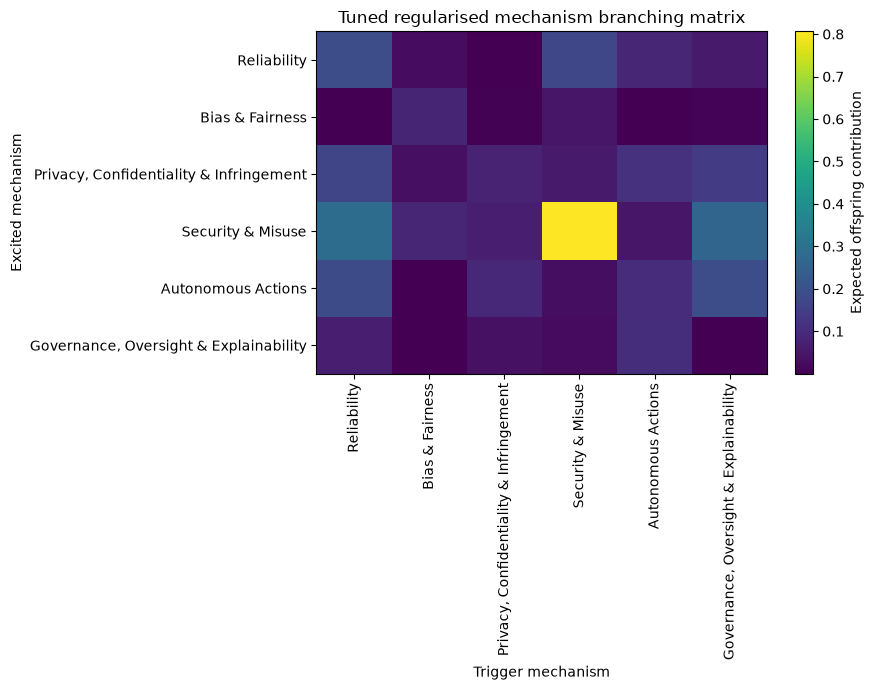

In [ ]:
latest_fold = selected_models["fold"].iloc[-1]
latest_selection = selected_models[selected_models["fold"] == latest_fold].iloc[0]

full_times, full_marks = prepare_marked_events(df, origin)
full_marked_fit = fit_marked_hawkes(
    full_times, full_marks, T_END,
    beta=float(latest_selection["beta"]),
    ridge=float(latest_selection["ridge"]),
    rho_max=float(latest_selection["rho_max"]),
    n_starts=N_STARTS_FINAL)

full_K = pd.DataFrame(full_marked_fit["K"], index=MECH_ORDER, columns=MECH_ORDER)
full_K.index.name = "excited_type"; full_K.columns.name = "trigger_type"
full_mu = pd.Series(full_marked_fit["mu"], index=MECH_ORDER, name="baseline_intensity_per_day")

full_summary = pd.DataFrame([{
    "success": full_marked_fit["success"], "message": full_marked_fit["message"],
    "beta": full_marked_fit["beta"], "half_life_days": np.log(2) / full_marked_fit["beta"],
    "ridge": full_marked_fit["ridge"], "rho_max": full_marked_fit["rho_max"],
    "smoothing": float(latest_selection["smoothing"]),
    "spectral_radius": full_marked_fit["spectral_radius"],
    "objective": full_marked_fit["objective"],
}])
display(full_summary); display(full_mu.sort_values(ascending=False)); display(full_K.round(3))

fig, ax = plt.subplots(figsize=(9, 7))
image = ax.imshow(full_K.to_numpy(), aspect="auto")
ax.set_xticks(range(len(MECH_ORDER)), MECH_ORDER, rotation=90)
ax.set_yticks(range(len(MECH_ORDER)), MECH_ORDER)
ax.set_title("Tuned regularised mechanism branching matrix")
ax.set_xlabel("Trigger mechanism"); ax.set_ylabel("Excited mechanism")
fig.colorbar(image, ax=ax, label="Expected offspring contribution")
plt.tight_layout(); plt.show()

In [ ]:
def baseline_design(times, centre):
    t = np.asarray(times, dtype=float)
    annual_angle = 2.0 * np.pi * t / YEAR_DAYS
    return np.column_stack([
        np.ones(len(t)),
        (t - centre) / YEAR_DAYS,
        np.sin(annual_angle),
        np.cos(annual_angle),
    ])

def baseline_intensity(times, coefficients, centre):
    design = baseline_design(np.atleast_1d(times), centre)
    log_intensity = design @ coefficients.T
    return np.exp(np.clip(log_intensity, -30, 20))

def dynamic_baseline_integral(coefficients, horizon, centre, step_days=INTEGRATION_STEP_DAYS):
    grid = np.arange(0.0, horizon, step_days)
    if len(grid) == 0 or grid[-1] < horizon:
        grid = np.append(grid, horizon)
    values = baseline_intensity(grid, coefficients, centre)
    integrals = np.trapezoid(values, grid, axis=0)
    return integrals

In [ ]:
import eval_common as _ec
AXIS = _ec.AXIS
OUT  = _ec.OUTPUT_DIR
MODEL = "regularised_marked_hawkes_tuned"

predictions_hawkes.to_csv(OUT / f"predictions_{MODEL}_{AXIS}.csv", index=False)
hawkes_overall.to_csv(OUT / f"metrics_{MODEL}_overall_{AXIS}.csv", index=False)
hawkes_by_fold.to_csv(OUT / f"metrics_{MODEL}_byfold_{AXIS}.csv", index=False)
selected_models.to_csv(OUT / f"selected_{MODEL}_{AXIS}.csv", index=False)

print("Saved to", OUT)
for f in [f"predictions_{MODEL}_{AXIS}.csv", f"metrics_{MODEL}_overall_{AXIS}.csv"]:
    print("  ", f)

Saved to model_outputs
   predictions_regularised_marked_hawkes_tuned_mechanism.csv
   metrics_regularised_marked_hawkes_tuned_overall_mechanism.csv
